In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import matplotlib
import lightgbm as lgb
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from itertools import combinations
from collections import Counter, defaultdict
import joblib
import random
import re

font_path = "C:/Windows/Fonts/gulim.ttc"
font = fm.FontProperties(fname=font_path).get_name()
matplotlib.rc("font", family=font)

In [70]:
rate_df = pd.read_csv("../data/rate_2026.csv").drop('Unnamed: 0',axis=1)
rate_df

,year,home_team,away_team,home_rate
0,2026,알제리,아르헨티나,0.000000
1,2026,알제리,벨기에,0.000000
2,2026,알제리,브라질,0.000000
3,2026,알제리,카메룬,0.333333
4,2026,알제리,콜롬비아,1.000000
...,...,...,...,...
1443,2026,우루과이,남아프리카공화국,1.000000
1444,2026,우루과이,대한민국,0.666667
1445,2026,우루과이,스페인,0.000000
1446,2026,우루과이,스위스,1.000000


In [71]:
team_df = pd.read_csv("../data/Final DF_2026_only.csv")
team_df

,Year,Nation,Eng_Nation,Q_WR,Q_GR,F_Rank,F_Point,F_Rd,F_Pd,Avg_Age,...,FS_5,FS_6,FS_7,FS_8,FS_9,FS_10,FS_11,FS_12,FS_13,FS_14
0,2026,미국,United States,0.50,1.816327,16,1670.04,-2,37.85,26.27,...,53.50,73.00,71.38,72.81,64.00,73.92,17.49,66.42,57.42,53.96
1,2026,멕시코,Mexico,0.53,1.613636,14,1688.38,-3,52.72,26.27,...,57.50,70.46,70.27,67.77,67.46,69.50,17.82,65.21,54.10,54.23
2,2026,캐나다,Canada,0.47,1.457143,26,1558.04,-12,55.73,27.58,...,52.46,68.54,69.54,74.08,65.12,71.08,17.26,62.27,50.59,52.92
3,2026,아르헨티나,Argentina,0.52,4.923077,3,1870.32,2,-18.70,29.00,...,63.88,71.42,72.38,71.88,73.50,70.12,18.46,75.35,58.49,61.69
4,2026,브라질,Brazil,0.44,1.375000,6,1761.60,1,-10.42,26.96,...,63.73,76.54,76.50,74.19,72.42,76.92,18.60,73.71,57.32,58.77
5,2026,잉글랜드,England,0.68,3.285714,4,1820.44,0,3.16,26.77,...,68.12,70.77,74.38,72.27,74.77,71.23,18.40,76.65,60.56,62.00
6,2026,프랑스,France,0.61,2.518519,2,1870.92,0,19.00,27.31,...,65.12,77.38,75.38,75.88,72.46,78.04,18.37,75.52,60.81,59.23
7,2026,독일,Germany,0.47,1.418605,12,1704.27,-1,12.08,28.69,...,61.81,65.08,72.58,77.15,75.62,68.35,18.79,75.33,58.99,60.38
8,2026,일본,Japan,0.58,4.454545,19,1640.47,3,0.87,26.81,...,55.69,73.42,70.54,67.92,65.69,72.04,17.14,64.44,53.72,55.31
9,2026,포르투갈,Portugal,0.76,3.230769,5,1779.55,-3,27.41,27.58,...,64.58,70.77,74.58,71.19,75.77,70.65,18.44,74.56,58.65,61.12


In [72]:
team_df.columns

Index(['Year', 'Nation', 'Eng_Nation', 'Q_WR', 'Q_GR', 'F_Rank', 'F_Point',
       'F_Rd', 'F_Pd', 'Avg_Age', 'Avg_Famous', 'FS_0', 'FS_1', 'FS_2', 'FS_3',
       'FS_4', 'FS_5', 'FS_6', 'FS_7', 'FS_8', 'FS_9', 'FS_10', 'FS_11',
       'FS_12', 'FS_13', 'FS_14'],
      dtype='object')

In [73]:
def make_group(df, teams_per_group=4, seed=None):
    if seed is not None:
        random.seed(seed)

    n_teams = len(df)
    n_groups = n_teams // teams_per_group
    groups = {chr(ord("A") + i): [] for i in range(n_groups)}

    # 시드별로 팀 나누기
    n_seeds = teams_per_group
    teams_per_seed = n_groups

    seeds = []
    for i in range(n_seeds):
        start = i * teams_per_seed
        end = (i + 1) * teams_per_seed
        seeds.append(df.index[start:end])

    # 각 조에 시드별로 한 팀씩 배치
    for seed_group in seeds:
        shuffled_indices = list(seed_group)  # Index → list 변환
        random.shuffle(shuffled_indices)
        for group_idx, team_idx in enumerate(shuffled_indices):
            group_name = chr(ord("A") + group_idx)
            groups[group_name].append(team_idx)

    return groups

In [74]:
def get_match_result(model, home, away, isgroupstage=False, threshold=0.4):
    cols = home.loc["Q_WR":"FS_14"].index
    diff = home[cols] - away[cols]

    diff_df = pd.DataFrame(diff).T  # 1행 DataFrame

    mask = (rate_df['year'] == home['Year']) & \
        (rate_df['home_team'] == home['Nation']) & \
        (rate_df['away_team'] == away['Nation'])

    home_rate_val = rate_df.loc[mask, 'home_rate'].values
    if len(home_rate_val) > 0:
        diff_df['home_rate'] = home_rate_val[0]
    else:
        diff_df['home_rate'] = 0  # 매칭값 없으면 기본값 0
    diff_df = diff_df.to_numpy(dtype=float).reshape(1, -1)
    pred = model.predict_proba(diff_df)[0]
    if isgroupstage:
        if pred[0] > threshold and pred[1] > threshold:
            return 0
        elif pred[1] > pred[0]:
            return 1
        else:
            return -1

    else:
        if pred[1] > pred[0]:
            return 1
        else:
            return -1

In [ ]:
def do_groupstage(model, team_df, groups):
    result = {}
    if len(team_df) == 32:
        n_result = 16
    elif len(team_df) == 48:
        n_result = 32
        thrid_lst = {}
    for g in groups.keys():
        matches = {}
        for idx in groups[g]:
            matches[idx] = 0
        for home, away in list(combinations(groups[g], 2)):
            match_result = get_match_result(
                model, team_df.iloc[home], team_df.iloc[away], isgroupstage=True
            )
            if match_result == 1:
                matches[home] += 3
            elif match_result == -1:
                matches[away] += 3
            else:
                matches[home] += 1
                matches[away] += 1
        result[g] = sorted(matches, key=lambda x: matches[x],reverse=True)[:3]
        if n_result == 32:
            thrid_lst[result[g][2]] = [matches[result[g][2]], g]
        result[g] = result[g][:2]
    if n_result == 32:
        sorted_lst = sorted(thrid_lst, key=lambda x: thrid_lst[x][0], reverse=True)[:8]
        for i in sorted_lst:
            result[thrid_lst[i][1]].append(i)
            pass
    return result

In [122]:
def make_tornament(team_df, group):
    # 1, 2, 3위 추출
    first_place = {k: v[0] for k, v in group.items()}
    second_place = {k: v[1] for k, v in group.items() if len(v) > 1}
    third_place_candidates = [(k, v[2]) for k, v in group.items() if len(v) > 2]
    
    # 3위 배정
    used_third = []
    def assign_third(allowed_groups):
        # allowed_groups 조건에 맞는 후보 리스트 생성
        candidates = [team for team in third_place_candidates 
                    if team[0] in allowed_groups and team[1] not in used_third]

        # 후보가 없는 경우 → 다른 후보 중 랜덤 선택
        if not candidates:
            fallback_candidates = [team for team in third_place_candidates if team[1] not in used_third]
            if not fallback_candidates:
                raise ValueError("⚠️ 모든 3위 후보가 이미 사용됨")
            choice = random.choice(fallback_candidates)
        else:
            choice = random.choice(candidates)

        used_third.append(choice[1])
        return choice[1]


    # 32강 매치업
    matches = []
    round_32 = [
        (first_place['E'], assign_third(["A","B","C","D","F","G","H","J","K","L"])),
        (first_place['I'], assign_third(["A","B","C","D","F","G","H","J","K","L"])),

        (second_place['A'], second_place['B']),
        (first_place['F'], second_place['C']),

        (first_place['C'], second_place['F']),
        (second_place['E'], second_place['I']),

        (first_place['A'], assign_third(["B","C","D","E","F","G","H","I","J","K"])),
        (first_place['L'], assign_third(["B","C","D","E","F","G","H","I","J","K"])),

        (second_place['K'], second_place['L']),
        (first_place['H'], second_place['J']),

        (first_place['D'], assign_third(["A","B","C","E","F","H","I","J","K","L"])),
        (first_place['G'], assign_third(["A","B","C","E","F","H","I","J","K","L"])),

        (first_place['J'], second_place['H']),
        (second_place['D'], second_place['G']),

        (first_place['B'], assign_third(["A","C","D","E","F","G","H","I","J","L"])),
        (first_place['K'], assign_third(["A","C","D","E","F","G","H","I","J","L"])),
    ] 


    for i, match in enumerate(round_32):
        matches.append(match)

    flat_list = [x for t in matches for x in t]
    return flat_list

In [ ]:
def do_tornament(model, team_df, groups):
    if len(team_df) == 32:
        rounds = ["16강", "8강", "4강", "준우승"]
    else:
        rounds = ["32강", "16강", "8강", "4강", "준우승"]
    tornament = make_tornament(team_df,groups)
    final={'조별리그':[]}
    for i in range(len(team_df)):
        if i not in tornament:
            final['조별리그'].append(i)
    for round in rounds:
        final[round] = []
        result_matches = []
        for i in range(0, len(tornament), 2):
            r = get_match_result(
                model, team_df.iloc[tornament[i]], team_df.iloc[tornament[i + 1]]
            )
            if r == 1:
                result_matches.append(tornament[i])
                final[round].append(tornament[i + 1])
            elif r == -1:
                result_matches.append(tornament[i + 1])
                final[round].append(tornament[i])
        tornament = result_matches
    final["우승"] = tornament
    return final

In [ ]:
def do_WorldCup(model, X):
    groups = make_group(X)
    result_group = do_groupstage(model, X, groups)
    final = do_tornament(model, X, result_group)
    return final

In [125]:
def do_simulate(model, X, iter=100):
    if len(X) == 32:
        rounds = ["조별리그","16강", "8강", "4강", "준우승", "우승"]
    else:
        rounds = ["조별리그","32강", "16강", "8강", "4강", "준우승", "우승"]
    final = {}
    for round in rounds:
        final[round] = []
    for i in range(iter):
        result = do_WorldCup(model, X)
        for r in result.keys():
            final[r] = final[r] + result[r]
    return final

In [126]:
def analyze_simulation(sim_results, df):
    # 전체 라운드
    rounds = list(sim_results.keys())

    # 팀별 라운드 도달 횟수 저장
    team_stats = defaultdict(lambda: Counter())
    for rnd, results in sim_results.items():
        for team_idx in results:
            team_stats[team_idx][rnd] += 1

    # DataFrame 생성
    data = []
    for team_idx, counts in team_stats.items():
        total_plays = sum(counts.values())  # 팀이 시뮬레이션에서 등장한 총 횟수
        row = {
            "Nation": df.loc[team_idx, "Nation"] if team_idx in df.index else team_idx
        }
        for rnd in rounds:
            row[rnd] = counts[rnd] / total_plays if total_plays > 0 else 0
        data.append(row)

    result_df = pd.DataFrame(data).fillna(0)

    return result_df


def normalize_win_prob(result_df):
    total_win_prob = result_df["우승"].sum()
    scaled_df = result_df[["Nation", "우승"]].copy()
    if total_win_prob > 0:
        scaled_df["우승"] = scaled_df["우승"] / total_win_prob
    return scaled_df.sort_values(by="우승", ascending=False).reset_index(drop=True)

In [127]:
X = team_df

In [128]:
# 예시 데이터프레임: df
priority_nations = ["멕시코", "미국", "캐나다"]

# 1) 우선순위 컬럼 생성: priority_nations에 속하면 0, 아니면 1
X["priority"] = X["Nation"].apply(lambda x: 0 if x in priority_nations else 1)

# 2) priority → F_Rank 순으로 정렬
df_sorted = X.sort_values(by=["priority", "F_Rank"], ascending=[True, True]).reset_index(drop=True)

# 3) priority 컬럼 삭제 (원치 않으면)
df_sorted = df_sorted.drop(columns=["priority"])

df_sorted

,Year,Nation,Eng_Nation,Q_WR,Q_GR,F_Rank,F_Point,F_Rd,F_Pd,Avg_Age,...,FS_5,FS_6,FS_7,FS_8,FS_9,FS_10,FS_11,FS_12,FS_13,FS_14
0,2026,멕시코,Mexico,0.53,1.613636,14,1688.38,-3,52.72,26.27,...,57.50,70.46,70.27,67.77,67.46,69.50,17.82,65.21,54.10,54.23
1,2026,미국,United States,0.50,1.816327,16,1670.04,-2,37.85,26.27,...,53.50,73.00,71.38,72.81,64.00,73.92,17.49,66.42,57.42,53.96
2,2026,캐나다,Canada,0.47,1.457143,26,1558.04,-12,55.73,27.58,...,52.46,68.54,69.54,74.08,65.12,71.08,17.26,62.27,50.59,52.92
3,2026,스페인,Spain,0.58,2.966667,1,1875.37,-2,38.95,28.04,...,65.88,73.27,71.88,68.04,73.58,73.15,19.59,77.27,56.42,62.92
4,2026,프랑스,France,0.61,2.518519,2,1870.92,0,19.00,27.31,...,65.12,77.38,75.38,75.88,72.46,78.04,18.37,75.52,60.81,59.23
5,2026,아르헨티나,Argentina,0.52,4.923077,3,1870.32,2,-18.70,29.00,...,63.88,71.42,72.38,71.88,73.50,70.12,18.46,75.35,58.49,61.69
6,2026,잉글랜드,England,0.68,3.285714,4,1820.44,0,3.16,26.77,...,68.12,70.77,74.38,72.27,74.77,71.23,18.40,76.65,60.56,62.00
7,2026,포르투갈,Portugal,0.76,3.230769,5,1779.55,-3,27.41,27.58,...,64.58,70.77,74.58,71.19,75.77,70.65,18.44,74.56,58.65,61.12
8,2026,브라질,Brazil,0.44,1.375000,6,1761.60,1,-10.42,26.96,...,63.73,76.54,76.50,74.19,72.42,76.92,18.60,73.71,57.32,58.77
9,2026,네덜란드,Netherlands,0.58,2.000000,7,1754.17,0,-5.78,28.50,...,60.73,67.73,72.38,75.58,72.77,70.46,18.74,73.27,61.14,59.04


In [130]:
model = joblib.load("xgb_d1_v5.pkl")
result_lst = do_simulate(model, df_sorted, 1)
result_df = analyze_simulation(result_lst, X)
scaled_win_df = normalize_win_prob(result_df)

{'A': [5, 14, 34, 44], 'B': [11, 20, 26, 46], 'C': [9, 18, 31, 37], 'D': [10, 21, 24, 47], 'E': [2, 16, 32, 43], 'F': [7, 19, 33, 38], 'G': [4, 12, 28, 42], 'H': [1, 15, 29, 40], 'I': [0, 13, 30, 41], 'J': [8, 17, 25, 36], 'K': [3, 23, 35, 45], 'L': [6, 22, 27, 39]}
{5: 7, 14: 7, 34: 3, 44: 0}
{11: 3, 20: 5, 26: 3, 46: 2}
{9: 9, 18: 6, 31: 3, 37: 0}
{10: 9, 21: 1, 24: 6, 47: 1}
{2: 3, 16: 7, 32: 2, 43: 2}
{7: 9, 19: 4, 33: 4, 38: 0}
{4: 9, 12: 6, 28: 3, 42: 0}
{1: 6, 15: 9, 29: 0, 40: 3}
{0: 3, 13: 7, 30: 7, 41: 0}
{8: 9, 17: 4, 25: 0, 36: 4}
{3: 9, 23: 4, 35: 4, 45: 0}
{6: 9, 22: 3, 27: 6, 39: 0}
{'A': [5, 14, 34], 'B': [20, 11, 26], 'C': [9, 18, 31], 'D': [10, 24], 'E': [16, 2], 'F': [7, 19, 33], 'G': [4, 12, 28], 'H': [15, 1, 40], 'I': [13, 30], 'J': [8, 17, 36], 'K': [3, 23, 35], 'L': [6, 27]}


In [84]:
from collections import Counter
count_dict = Counter(result_lst['우승'])
print(count_dict)
nation_dict={}
for i in count_dict.keys():
    nation_dict[X['Nation'].iloc[i]]=count_dict[i]
print(nation_dict)

Counter({11: 514, 6: 486})
{'스페인': 514, '프랑스': 486}


In [85]:
result_df.to_csv('2026_predict_with_seed.csv',index=False,encoding='utf-8-sig')

In [86]:
result_df

,Nation,조별리그,32강,16강,8강,4강,준우승,우승
0,미국,0.057,0.423,0.442,0.078,0.000,0.000,0.000
1,일본,0.042,0.599,0.345,0.014,0.000,0.000,0.000
2,호주,0.534,0.463,0.003,0.000,0.000,0.000,0.000
3,이란,0.989,0.011,0.000,0.000,0.000,0.000,0.000
4,나이지리아,0.204,0.631,0.155,0.010,0.000,0.000,0.000
5,사우디아라비아,0.656,0.344,0.000,0.000,0.000,0.000,0.000
6,세르비아,0.201,0.594,0.185,0.020,0.000,0.000,0.000
7,스웨덴,0.210,0.506,0.246,0.038,0.000,0.000,0.000
8,칠레,0.907,0.091,0.002,0.000,0.000,0.000,0.000
9,온두라스,1.000,0.000,0.000,0.000,0.000,0.000,0.000


In [90]:
import pandas as pd

# 데이터프레임이 df 라고 가정
sort_order = ["우승", "준우승", "4강", "8강", "16강", "32강"]

df_sorted = result_df.sort_values(
    by=sort_order,
    ascending=[False] * len(sort_order)  # 모든 기준을 내림차순 정렬
).reset_index(drop=True)

df_sorted.to_csv('2026_predict_with_seed.csv',index=False,encoding='utf-8-sig')

In [87]:
scaled_win_df.head()

,Nation,우승
0,스페인,0.514
1,프랑스,0.486
2,미국,0.000
3,일본,0.000
4,나이지리아,0.000


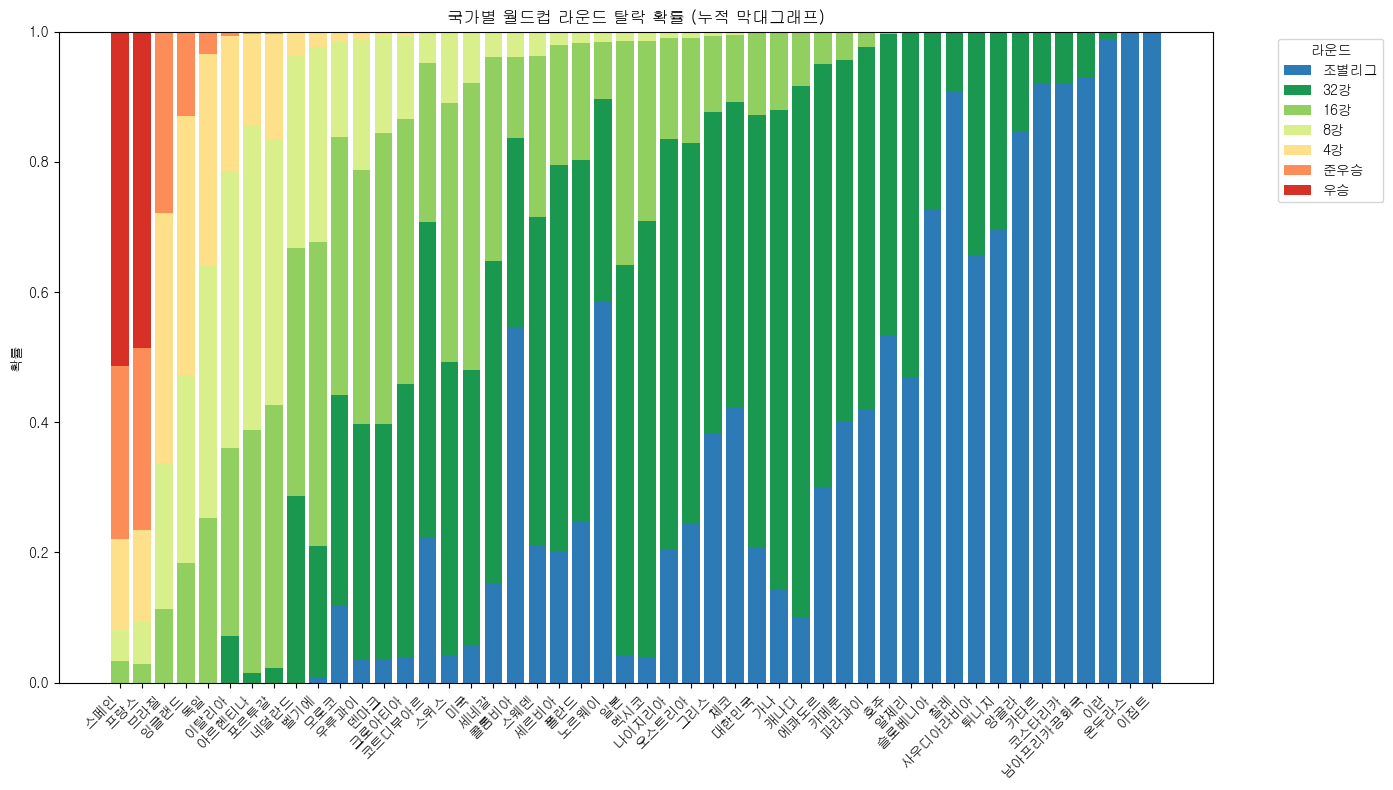

In [93]:
import pandas as pd
import matplotlib.pyplot as plt

# CSV 또는 DataFrame 읽기
# df = pd.read_csv("worldcup_probs.csv")  # CSV에서 불러올 때
# 지금은 예시로 df가 있다고 가정

# 시각화에 사용할 라운드 순서 (Nation 제외)
rounds = ["조별리그", "32강", "16강", "8강", "4강", "준우승", "우승"]

# 색상 팔레트 (원하는 대로 수정 가능)
colors = [
    "#2c7bb6", "#1a9850", "#91cf60",
    "#d9ef8b", "#fee08b", "#fc8d59", "#d73027"
]

# 그래프 크기
plt.figure(figsize=(14, 8))

# 누적 막대그래프
bottom = None
for i, rnd in enumerate(rounds):
    plt.bar(
        df_sorted["Nation"],
        df_sorted[rnd],
        bottom=bottom,
        label=rnd,
        color=colors[i],
    )
    # bottom 업데이트 (누적 쌓기)
    if bottom is None:
        bottom = df_sorted[rnd].copy()
    else:
        bottom += df_sorted[rnd]

plt.xticks(rotation=45, ha="right")
plt.ylabel("확률")
plt.title("국가별 월드컵 라운드 탈락 확률 (누적 막대그래프)")
plt.legend(title="라운드", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

C:\Users\chris\AppData\Local\Temp\ipykernel_10592\2643668721.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


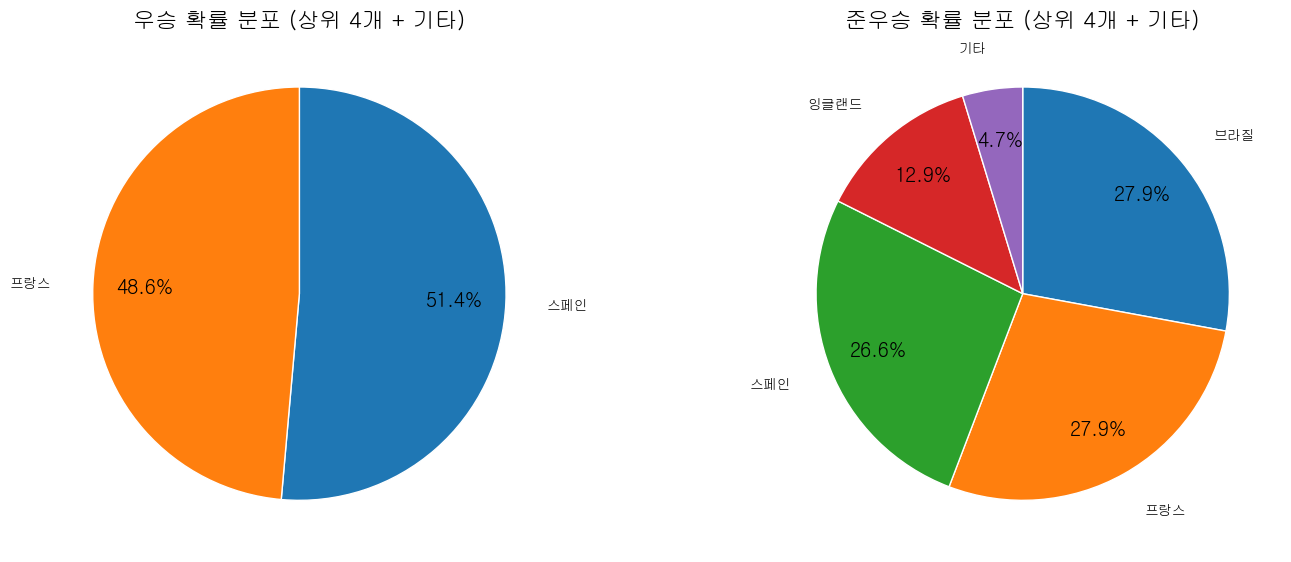

In [120]:
import matplotlib.pyplot as plt
from collections import Counter

def plot_win_runner_pie_nice_outer_labels(result_lst, X, top_n=4):
    total_runs = len(result_lst)

    fig, axes = plt.subplots(1, 2, figsize=(16, 8), gridspec_kw={'wspace': 0.4})

    def prepare_data(column_name):
        count = Counter(result_lst[column_name])
        prob_dict = {X['Nation'].iloc[i]: count[i] / total_runs for i in count.keys()}
        sorted_probs = dict(sorted(prob_dict.items(), key=lambda x: x[1], reverse=True))

        labels, sizes = [], []
        other_total = 0
        for idx, (nation, prob) in enumerate(sorted_probs.items()):
            if idx < top_n:
                labels.append(nation)
                sizes.append(prob)
            else:
                other_total += prob
        if other_total > 0:
            labels.append("기타")
            sizes.append(other_total)

        return labels, sizes

    # ===== 우승 파이 =====
    win_labels, win_sizes = prepare_data("우승")
    wedges1, texts1, autotexts1 = axes[0].pie(
        win_sizes,
        labels=win_labels,
        autopct="%1.1f%%",
        pctdistance=0.75,
        labeldistance=1.2,
        startangle=90,
        counterclock=False,
        wedgeprops={"edgecolor": "w", "linewidth": 1}
    )
    axes[0].set_title(f"우승 확률 분포 (상위 {top_n}개 + 기타)", fontsize=16, fontweight="bold")

    # ===== 준우승 파이 =====
    runner_labels, runner_sizes = prepare_data("준우승")
    wedges2, texts2, autotexts2 = axes[1].pie(
        runner_sizes,
        labels=runner_labels,
        autopct="%1.1f%%",
        pctdistance=0.75,
        labeldistance=1.2,
        startangle=90,
        counterclock=False,
        wedgeprops={"edgecolor": "w", "linewidth": 1}
    )
    axes[1].set_title(f"준우승 확률 분포 (상위 {top_n}개 + 기타)", fontsize=16, fontweight="bold")

    # 글자 크기 및 bold 설정
    for autotext in autotexts1 + autotexts2:
        autotext.set_fontsize(14)
        autotext.set_fontweight("bold")
        autotext.set_color('black')

    plt.tight_layout()
    plt.show()

# 사용 예시
plot_win_runner_pie_nice_outer_labels(result_lst, X, top_n=4)


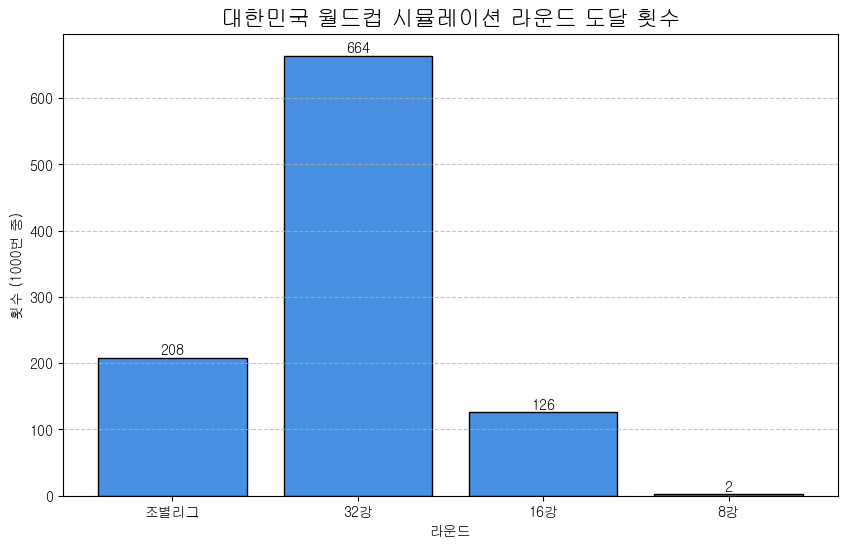

In [113]:
import matplotlib.pyplot as plt

def plot_korea_histogram(df, korea_index=24, total_simulations=1000):
    korea_row = df.iloc[korea_index]

    rounds = ["조별리그", "32강", "16강", "8강"]
    probabilities = korea_row[rounds].values

    # 확률 → 횟수 변환
    counts = probabilities * total_simulations

    plt.figure(figsize=(10, 6))
    bars = plt.bar(rounds, counts, color="#4a90e2", edgecolor="black")

    # 그래프에 값 표시
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2,
                 height + 5,
                 f"{int(height)}",
                 ha="center", fontsize=10)

    plt.title("대한민국 월드컵 시뮬레이션 라운드 도달 횟수", fontsize=16)
    plt.ylabel("횟수 (1000번 중)")
    plt.xlabel("라운드")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

# 사용 예시
plot_korea_histogram(result_df, korea_index=24, total_simulations=1000)